# L13c Example: NanoGPT on Tiny Shakespeare
This example trains a small character-level decoder-only language model on the Tiny Shakespeare corpus and samples from it. The goal is to make every component of the L13c lecture concrete: a real causal-attention layer, a real next-token-prediction training loop, and real autoregressive sampling with greedy, temperature, and top-$k$ decoding.

> __Problem statement.__ We have a single text file, the complete works of Shakespeare concatenated into about $1.1$ million characters. We want to train a small language model (around $112{,}000$ parameters, two transformer blocks, four heads) on this file by next-token prediction, and then use it to generate new Shakespeare-like text starting from a prompt. The trained model will not produce real Shakespearean prose, because it is small and the corpus is short, but it will reproduce the surface structure: speech tags, character names, line breaks, and roughly word-shaped sequences of characters.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Build and train a decoder-only language model from scratch:__ Assemble a NanoGPT model from the `CausalAttention`, `DecoderBlock`, and `NanoGPT` building blocks in `src/`, and train it on Tiny Shakespeare with next-token prediction cross-entropy loss.
> * __Generate text with three sampling strategies:__ Use greedy decoding, temperature sampling, and top-$k$ sampling on the trained model and explain by inspection how each strategy trades off determinism against diversity.
> * __Read a causal attention pattern:__ Plot the attention weights of one of the trained heads on a real input sequence and identify the lower-triangular structure imposed by the causal mask.

Let's get started!
___

## Setup
We load the L13c Julia environment, which brings in `Flux`, `NNlib`, `JLD2`, our custom `Shakespeare.jl`, `CausalAttention.jl`, `DecoderBlock.jl`, `NanoGPT.jl`, and `Sample.jl` files in the `src/` directory.

In [1]:
include("Include.jl");
Random.seed!(42);

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13c`


## Load the Tiny Shakespeare Corpus
The corpus is the same one used by Karpathy's char-rnn demos. The first run downloads the file (~1.1 MB) from the char-rnn GitHub repo and caches it in `data/input.txt`. Subsequent runs use the cached copy.

In [2]:
path = download_shakespeare(_PATH_TO_DATA);
text = read(path, String);
@info "corpus loaded" path=path n_chars=length(text)
println();
println("First 200 characters of the corpus:");
println("---");
println(text[1:200]);
println("---");

┌ Info: corpus loaded
│   path = "/Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13c/data/input.txt"
└   n_chars = 1115394



First 200 characters of the corpus:
---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you
---


### Build the Character Vocabulary
The vocabulary is the set of unique characters in the corpus. Each unique character is assigned an integer id starting from 1.

In [3]:
vocab = build_vocab(text);
@info "vocabulary built" vocab_size=vocab.vocab_size
println("Vocab characters: \"", join(sort(collect(keys(vocab.char_to_id))), ""), "\"")

┌ Info: vocabulary built
└   vocab_size = 65


Vocab characters: "
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"


In [4]:
# encode/decode roundtrip sanity check
sample = "First Citizen:";
ids = encode(sample, vocab);
println("encoded: ", ids);
println("decoded back: \"", decode(ids, vocab), "\"");

encoded: [19, 48, 57, 58, 59, 2, 16, 48, 59, 48, 65, 44, 53, 11]
decoded back: "First Citizen:"


## Encode the Corpus and Split Into Train and Validation
We encode the entire corpus into an integer vector, then hold out the last 10% as a validation set so we can monitor for overfitting.

In [5]:
data = encode(text, vocab);
n_train = round(Int, 0.9 * length(data));
const TRAIN_DATA = data[1:n_train];
const VAL_DATA   = data[n_train+1:end];
@info "train/val split" n_train=length(TRAIN_DATA) n_val=length(VAL_DATA)

┌ Info: train/val split
│   n_train = 1003855
└   n_val = 111539


## Build the NanoGPT Model
The model is a decoder-only language model with two transformer blocks, four attention heads, model dimension 64, and a context length of 64 characters. The expected parameter count is roughly $2 V d + n_{\max} d + L\,(12 d^{2} + 9 d) + 2 d \approx 112{,}000$.

In [6]:
const VOCAB     = vocab.vocab_size;
const D_MODEL   = 64;
const N_HEADS   = 4;
const N_LAYERS  = 2;
const CTX_LEN   = 64;
const D_FF      = 4 * D_MODEL;
const BATCHSIZE = 32;

Random.seed!(42);
model = NanoGPT(VOCAB, D_MODEL, N_HEADS, N_LAYERS, CTX_LEN; d_ff = D_FF);
@info "NanoGPT model built" n_params=n_parameters(model) vocab=VOCAB d_model=D_MODEL n_heads=N_HEADS n_layers=N_LAYERS ctx_len=CTX_LEN

┌ Info: NanoGPT model built
│   n_params = 112000
│   vocab = 65
│   d_model = 64
│   n_heads = 4
│   n_layers = 2
└   ctx_len = 64


## Train the Model (or Load a Saved Checkpoint)
We train with Adam at learning rate $3\times 10^{-3}$ for $5$ epochs of $200$ iterations each, sampling random `(input, target)` chunks from the training corpus on each iteration. The first run trains and saves a checkpoint to `data/nanogpt_d64_h4_l2.jld2`; subsequent runs detect the checkpoint and load it instead of retraining.

In [7]:
const CHECKPOINT_PATH = joinpath(_PATH_TO_DATA, "nanogpt_d64_h4_l2.jld2");
const N_EPOCHS = 5;
const N_ITERS_PER_EPOCH = 200;
const LR = 3.0f-3;

train_history = Float32[];
val_history   = Float32[];

if isfile(CHECKPOINT_PATH)
    @info "Loading pre-trained checkpoint" path=CHECKPOINT_PATH
    saved = JLD2.load(CHECKPOINT_PATH);
    Flux.loadmodel!(model, saved["model_state"]);
    train_history = saved["train_history"];
    val_history   = saved["val_history"];
    @info "Loaded model from checkpoint"
else
    @info "No checkpoint found, training from scratch..."
    Random.seed!(42);
    opt = Flux.setup(Adam(LR), model);
    for epoch in 1:N_EPOCHS
        epoch_losses = Float32[];
        for it in 1:N_ITERS_PER_EPOCH
            Xb, Yb = sample_batch(TRAIN_DATA, BATCHSIZE, CTX_LEN);
            l, gs = Flux.withgradient(model) do m
                nanogpt_loss(m, Xb, Yb)
            end
            push!(epoch_losses, l);
            Flux.update!(opt, model, gs[1]);
        end
        train_l = mean(epoch_losses);
        push!(train_history, train_l);
        Xv, Yv = sample_batch(VAL_DATA, BATCHSIZE, CTX_LEN);
        val_l = nanogpt_loss(model, Xv, Yv);
        push!(val_history, val_l);
        @info "epoch" epoch train_loss=round(train_l, digits=4) val_loss=round(val_l, digits=4)
    end
    JLD2.jldsave(CHECKPOINT_PATH;
                  model_state = Flux.state(model),
                  train_history = train_history,
                  val_history = val_history);
    @info "Saved checkpoint" path=CHECKPOINT_PATH
end

┌ Info: Loading pre-trained checkpoint
└   path = "/Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13c/data/nanogpt_d64_h4_l2.jld2"
[ Info: Loaded model from checkpoint


### Training Loss Curve
The training and validation losses both decrease steadily over the five epochs and stay close together, which means the model is learning the corpus without overfitting.

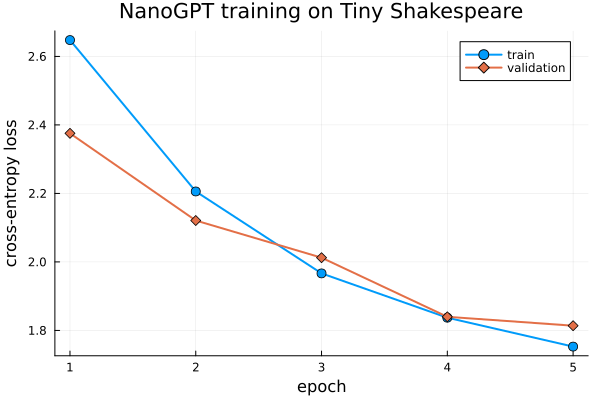

In [8]:
plot(1:length(train_history), train_history;
     xlabel = "epoch", ylabel = "cross-entropy loss",
     label = "train",
     title = "NanoGPT training on Tiny Shakespeare",
     linewidth = 2, marker = :circle, markersize = 5,
     legend = :topright);
plot!(1:length(val_history), val_history;
      label = "validation",
      linewidth = 2, marker = :diamond, markersize = 5)

## Sampling: Three Decoding Strategies
Now that the model is trained, we generate text by autoregressive sampling. We use the same prompt `"ROMEO:"` for each strategy so the differences come from the decoding rule, not the prompt.

In [9]:
prompt = "ROMEO:";
n_new = 250;

### Greedy Decoding ($\tau = 0$)
At every step, pick the token with the highest logit. This is deterministic, but it tends to fall into repetition loops because the most-likely continuation of "the the the" is often "the" again.

In [10]:
println(sample_text(model, vocab, prompt, n_new; temperature = 0))

ROMEO:
A my the so the soul the soul the soul the son.

KING RICHARD II:
And the she so the son the will the son the will the son
The the son the son the will the son the will the son
The the son the son the will the son the will the son
The the son the so


### Temperature Sampling ($\tau = 0.8$)
Scale the logits by $1/\tau$ before softmax. With $\tau = 0.8$ the distribution stays sharp but is no longer deterministic, so the model can escape repetition loops.

In [11]:
println(sample_text(model, vocab, prompt, n_new; temperature = 0.8, rng = MersenneTwister(7)))

ROMEO:
What be it sir; advoust.

LEONTES:
But ass, th you quitoo the come is a verl,
But not he deprish gelfeith had heaved word cains the will
Have she beas, fries tcoun sayesice, and thring wips,
God and he know fairs do hathly wils for to broth
Of Heart


### Top-$k$ Sampling ($\tau = 0.8$, $k = 10$)
Same as temperature sampling but restricted to the $k$ highest-logit tokens at every step. This avoids occasional very-low-probability "junk" tokens that pure temperature sampling can produce.

In [12]:
println(sample_text(model, vocab, prompt, n_new; temperature = 0.8, top_k = 10, rng = MersenneTwister(7)))

ROMEO:
What be it sir; advoust, and the she hades to at a pasting.

MENENIUS:
By so did me, sir, and the be sished and swee
With had thou drese for my shall bide it tanin thy to his this well their his appy in thion
This the soungs it in torn this man the 


## Visualizing the Causal Attention Pattern
Each attention head in the model produces a $T\times T$ matrix of attention weights at each forward pass. Because of the causal mask, every row $i$ has zero weight at all columns $j > i$, so the matrix is strictly lower-triangular. We extract the attention weights from the first layer's first head on a sample input and plot them as a heatmap, with the actual characters labeled on both axes.

In [13]:
# pick a sample input from the validation set
Random.seed!(2026);
Xb, _ = sample_batch(VAL_DATA, 1, CTX_LEN);
input_chars = decode(Xb[:, 1], vocab);
println("Input sequence:");
println("---");
println(input_chars);
println("---");

Input sequence:
---
s to close our stomachs up,
After our great good cheer. Pray you
---


In [14]:
# get the embeddings the way the model would, then run them through the
# first decoder block's causal attention layer (after the pre-norm) to recover
# its (T, T, n_heads, B) attention weights
flat_ids = vec(Xb);
tok_e = model.tok_emb[:, flat_ids];
H0 = reshape(tok_e, D_MODEL, CTX_LEN, 1) .+ reshape(model.pos_emb[:, 1:CTX_LEN], D_MODEL, CTX_LEN, 1);
H_norm = model.blocks[1].ln1(H0);
attn_w = causal_attention_weights(model.blocks[1].attn, H_norm);
@info "attention weights" shape=size(attn_w)

┌ Info: attention weights
└   shape = (64, 64, 4, 1)


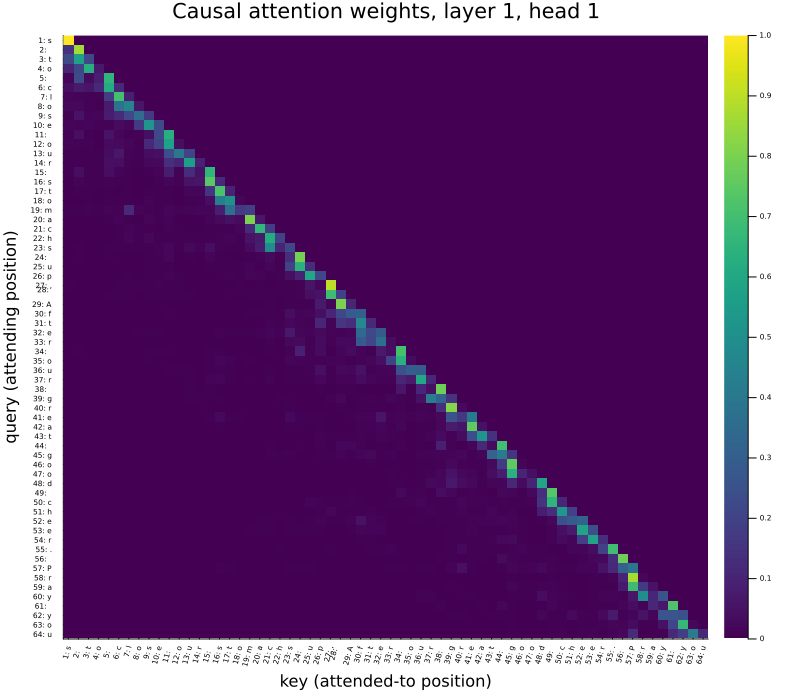

In [15]:
# plot the attention weights for head 1
A = attn_w[:, :, 1, 1];
# axis labels: position indices, with characters as tick labels
T = size(A, 1);
labels = [c == '\n' ? "\\n" : string(c) for c in input_chars];
tick_labels = ["$(i): $(labels[i])" for i in 1:T];
heatmap(1:T, 1:T, A;
        xlabel = "key (attended-to position)",
        ylabel = "query (attending position)",
        title  = "Causal attention weights, layer 1, head 1",
        color  = :viridis,
        size   = (800, 700),
        yflip  = true,
        xticks = (1:T, tick_labels),
        yticks = (1:T, tick_labels),
        xrotation = 75,
        xtickfont = font(5),
        ytickfont = font(5))

### Things to Think About
The plot above shows you exactly what the causal mask buys: every row of the heatmap has nonzero values only in the lower-left triangle, which is the structural constraint we wanted from the lecture. A few questions to think through:

* __What does each row of the heatmap mean?__ Row $i$ is the attention distribution that the model uses when computing the output at position $i$. Look at one row of the lower-triangular region. Where does the model put most of its attention? On the immediately preceding token, on a few specific earlier tokens, or spread evenly?
* __Why are the entries in the upper-right triangle exactly zero?__ The causal mask sets the score at every $(i, j)$ with $j > i$ to $-10^{9}$ before softmax, and $\exp(-10^{9})$ rounds to zero. This is the empirical confirmation that the mask is doing its job: information from the future cannot leak into the past, no matter what the input contains.
* __What did greedy decoding produce, and why is it bad?__ Look at the greedy sample above and compare it to the temperature samples. Greedy decoding always picks the same continuation given the same context, so once it enters a repeating pattern it can never escape. Temperature sampling and top-$k$ sampling break this loop by injecting randomness, at the cost of reproducibility.
* __What has the model NOT learned?__ Read one of the temperature samples carefully. The model has learned line breaks, speech tags ("ROMEO:" / "MENENIUS:"), and roughly word-shaped sequences of characters, but it has not learned actual word spellings, grammar, or semantics. What would you change about the experiment to push the model toward more coherent output? (Larger model, more training, larger context window, word-level rather than character-level tokenization, more data, or a combination of these.)
* __How does parameter count scale with model dimension?__ The dominant term in the decoder-stack parameter count is $L\cdot 12 d^{2}$. If you double $d$ from 64 to 128, by what factor does the per-block parameter count increase? Verify your prediction by counting parameters of a $d=128$ model with the same $L$ and $H$.

## Summary
We trained a small decoder-only language model on Tiny Shakespeare and sampled from it with three different decoding strategies. Every component of the L13c lecture, the causal mask, the decoder block, the embedding tables, and the next-token cross-entropy loss, became something concrete you could read off the model and inspect.

> __Key Takeaways:__
>
> * **A small decoder-only LM is enough to see the lecture's claims in practice.** With ~112k parameters and 1000 gradient steps on Tiny Shakespeare, the model already produces output with the right surface structure (line breaks, character names, speech tags), even though the actual word content is gibberish. You do not need a billion-parameter model to convince yourself that next-token prediction works.
> * **Greedy decoding fails for the reason the lecture predicted.** Pick the token with the highest logit at every step and the model immediately enters a repetition loop. Temperature and top-$k$ sampling fix this by injecting controlled randomness, which is why every modern LM-based generation system uses some form of stochastic decoding.
> * **The causal attention heatmap is the most direct visualization of the causal mask.** A trained head's attention weights are exactly lower-triangular, with all upper-triangular entries equal to zero. This is the architectural constraint that enables parallel training of an autoregressive model.
___